# Pipeline de classificação de risco de crédito

Este notebook simula um cenário em que uma instituição deseja **treinar um modelo supervisionado** para apoiar decisões de concessão de crédito. O objetivo é estimar, com base em variáveis de perfil e solicitação, se o tomador tende a representar **maior ou menor risco** de inadimplência (rótulo binário).

**Importante:** os dados são **sintéticos**, apenas para fins didáticos. Em produção seriam necessários governança de dados, explicabilidade regulatória, monitoramento de viés e conformidade com a legislação local (por exemplo, LGPD no Brasil).

## 1. Dependências e configuração

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Geração de dados sintéticos

Simulamos uma base com variáveis comuns em análise de crédito e um rótulo `inadimplente` (1 = houve default no período observado, 0 = adimplente). A relação entre variáveis e rótulo é propositalmente ruidosa, como em dados reais.

In [3]:
def gerar_base_credito(n_amostras: int = 5000, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    n = n_amostras

    idade = rng.integers(22, 66, size=n)
    renda_mensal = rng.lognormal(mean=np.log(3500), sigma=0.45, size=n).round(2)
    tempo_emprego_anos = rng.exponential(scale=4, size=n).clip(0, 35).round(1)
    score_interno = rng.normal(650, 90, size=n).clip(300, 900).astype(int)
    valor_solicitado = rng.lognormal(mean=np.log(8000), sigma=0.6, size=n).round(2)
    num_parcelas = rng.choice([6, 12, 18, 24, 36, 48], size=n, p=[0.1, 0.25, 0.2, 0.2, 0.15, 0.1])
    tipo_renda = rng.choice(["CLT", "autonomo", "aposentado"], size=n, p=[0.65, 0.22, 0.13])
    possui_restricao = rng.choice(["sim", "nao"], size=n, p=[0.12, 0.88])

    # Probabilidade base de default (logit simplificado)
    z = (
        -3.2
        - 0.025 * (score_interno - 650)
        - 0.00008 * renda_mensal
        + 0.00002 * valor_solicitado
        + 0.015 * (num_parcelas / 12)
        - 0.04 * tempo_emprego_anos
    )
    z = np.asarray(z, dtype=float)
    z += np.where(possui_restricao == "sim", 0.85, 0)
    z += np.where(tipo_renda == "autonomo", 0.35, 0)
    z += rng.normal(0, 0.35, size=n)
    p_default = 1 / (1 + np.exp(-z))
    inadimplente = rng.binomial(1, p_default)

    return pd.DataFrame(
        {
            "idade": idade,
            "renda_mensal": renda_mensal,
            "tempo_emprego_anos": tempo_emprego_anos,
            "score_interno": score_interno,
            "valor_solicitado": valor_solicitado,
            "num_parcelas": num_parcelas,
            "tipo_renda": tipo_renda,
            "possui_restricao": possui_restricao,
            "inadimplente": inadimplente,
        }
    )


df = gerar_base_credito(6000)
df.head()

,idade,renda_mensal,tempo_emprego_anos,score_interno,valor_solicitado,num_parcelas,tipo_renda,possui_restricao,inadimplente
0,25,5630.15,0.3,501,5234.99,24,CLT,nao,0
1,56,2491.57,9.6,593,8264.73,18,CLT,sim,0
2,50,1020.17,1.0,695,12435.70,12,CLT,nao,0
3,41,1580.32,11.7,527,14883.12,48,CLT,nao,0
4,41,6635.91,2.7,618,12856.88,24,CLT,nao,0


In [13]:
df

,idade,renda_mensal,tempo_emprego_anos,score_interno,valor_solicitado,num_parcelas,tipo_renda,possui_restricao,inadimplente
0,25,5630.15,0.3,501,5234.99,24,CLT,nao,0
1,56,2491.57,9.6,593,8264.73,18,CLT,sim,0
2,50,1020.17,1.0,695,12435.70,12,CLT,nao,0
3,41,1580.32,11.7,527,14883.12,48,CLT,nao,0
4,41,6635.91,2.7,618,12856.88,24,CLT,nao,0
...,...,...,...,...,...,...,...,...,...
5995,31,3065.40,1.3,652,7181.56,6,CLT,nao,0
5996,59,2565.48,2.6,702,4456.83,18,CLT,nao,0
5997,65,5221.28,5.0,631,2248.54,12,CLT,nao,1
5998,55,1848.94,2.7,660,3165.64,12,CLT,sim,0


In [4]:
df["inadimplente"].value_counts(normalize=True).round(3)

inadimplente
0    0.88
1    0.12
Name: proportion, dtype: float64

## 3. Análise exploratória rápida

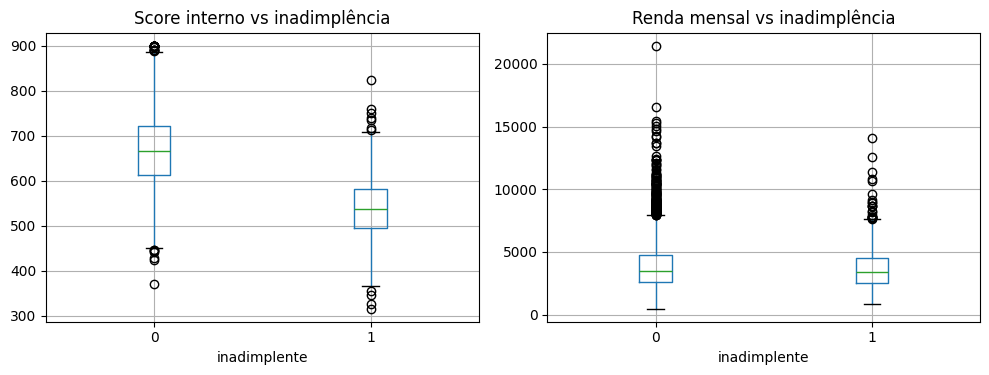

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column="score_interno", by="inadimplente", ax=axes[0])
axes[0].set_title("Score interno vs inadimplência")
axes[0].set_xlabel("inadimplente")
df.boxplot(column="renda_mensal", by="inadimplente", ax=axes[1])
axes[1].set_title("Renda mensal vs inadimplência")
axes[1].set_xlabel("inadimplente")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 4. Separação treino / teste e pré-processamento

Usamos `ColumnTransformer` para tratar colunas numéricas e categóricas de forma unificada e evitar vazamento de informação do conjunto de teste para o treino (tudo fica dentro do `Pipeline`).

In [6]:
TARGET = "inadimplente"
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

num_cols = ["idade", "renda_mensal", "tempo_emprego_anos", "score_interno", "valor_solicitado", "num_parcelas"]
cat_cols = ["tipo_renda", "possui_restricao"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

X_train.shape, X_test.shape

((4500, 8), (1500, 8))

## 5. Pipeline do classificador

Encadeamos pré-processamento + **regressão logística** (interpretável via coeficientes). Alternativas comuns em produção incluem *Random Forest* e *Gradient Boosting*.

In [8]:
clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)

model_pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        ("model", clf),
    ]
)

model_pipe.fit(X_train, y_train)
y_proba = model_pipe.predict_proba(X_test)[:, 1]
y_pred = model_pipe.predict(X_test)

print("ROC-AUC (teste):", round(roc_auc_score(y_test, y_proba), 4))

ROC-AUC (teste): 0.9036


### Validação cruzada (estabilidade do desempenho)

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(model_pipe, X_train, y_train, cv=cv, scoring="roc_auc")
print("ROC-AUC por fold:", scores.round(4))
print("Média ± desvio:", f"{scores.mean():.4f} ± {scores.std():.4f}")

ROC-AUC por fold: [0.9179 0.887  0.8969 0.9207 0.9   ]
Média ± desvio: 0.9045 ± 0.0128


## 6. Avaliação no conjunto de teste

              precision    recall  f1-score   support

  adimplente       0.97      0.82      0.89      1319
inadimplente       0.39      0.82      0.53       181

    accuracy                           0.82      1500
   macro avg       0.68      0.82      0.71      1500
weighted avg       0.90      0.82      0.85      1500



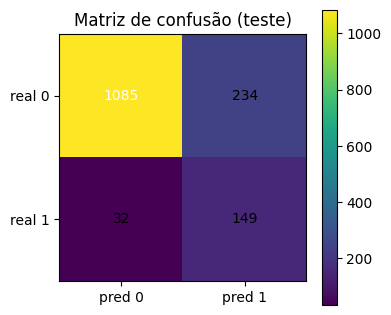

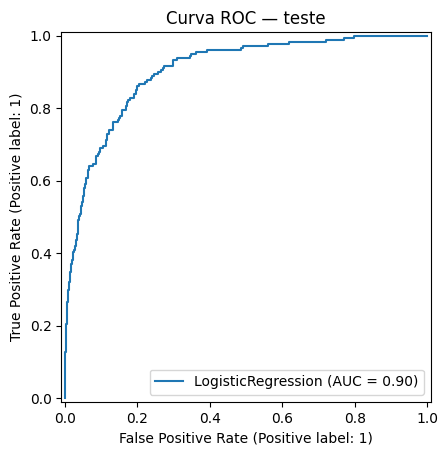

In [10]:
print(classification_report(y_test, y_pred, target_names=["adimplente", "inadimplente"]))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["pred 0", "pred 1"])
ax.set_yticklabels(["real 0", "real 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="w" if cm[i, j] > cm.max() / 2 else "k")
ax.set_title("Matriz de confusão (teste)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba, name="LogisticRegression")
plt.title("Curva ROC — teste")
plt.show()

## 7. Explicabilidade simplificada (coeficientes na escala padronizada)

Após `StandardScaler`, os coeficientes da regressão logística indicam a direção do efeito sobre o log-odds de inadimplência. Isso **não substitui** ferramentas como SHAP em modelos mais complexos, mas ajuda na comunicação com negócio.

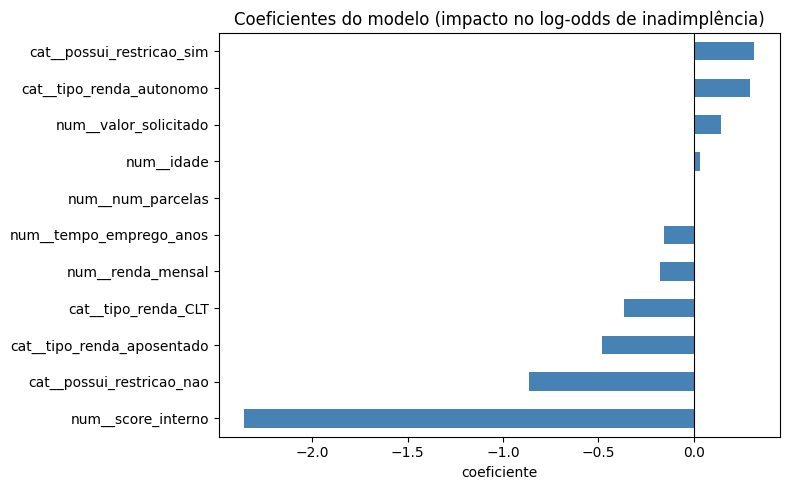

(num__score_interno           -2.355780
 cat__possui_restricao_nao    -0.864320
 cat__tipo_renda_aposentado   -0.477842
 cat__tipo_renda_CLT          -0.362248
 num__renda_mensal            -0.174775
 num__tempo_emprego_anos      -0.157154
 num__num_parcelas             0.005417
 num__idade                    0.035090
 dtype: float64,
 cat__tipo_renda_CLT         -0.362248
 num__renda_mensal           -0.174775
 num__tempo_emprego_anos     -0.157154
 num__num_parcelas            0.005417
 num__idade                   0.035090
 num__valor_solicitado        0.144319
 cat__tipo_renda_autonomo     0.295261
 cat__possui_restricao_sim    0.319492
 dtype: float64)

In [11]:
prep = model_pipe.named_steps["prep"]
model = model_pipe.named_steps["model"]

feature_names = prep.get_feature_names_out()
coefs = pd.Series(model.coef_.ravel(), index=feature_names).sort_values()

plt.figure(figsize=(8, 5))
coefs.plot(kind="barh", color="steelblue")
plt.axvline(0, color="k", linewidth=0.8)
plt.title("Coeficientes do modelo (impacto no log-odds de inadimplência)")
plt.xlabel("coeficiente")
plt.tight_layout()
plt.show()

coefs.head(8), coefs.tail(8)

## 8. Simulação de decisão para um novo perfil

A saída `predict_proba` pode ser comparada a **políticas** (por exemplo: aprovar se probabilidade de default < 25%, ou encaminhar para análise manual em faixas intermediárias).

In [12]:
novo = pd.DataFrame(
    [
        {
            "idade": 34,
            "renda_mensal": 4200.0,
            "tempo_emprego_anos": 5.0,
            "score_interno": 620,
            "valor_solicitado": 12000.0,
            "num_parcelas": 24,
            "tipo_renda": "CLT",
            "possui_restricao": "nao",
        }
    ]
)

p = model_pipe.predict_proba(novo)[0, 1]
print(f"Probabilidade estimada de inadimplência: {p:.1%}")
print("Rótulo binário (limiar 0.5):", int(model_pipe.predict(novo)[0]))

Probabilidade estimada de inadimplência: 27.2%
Rótulo binário (limiar 0.5): 0


## 9. Limitações e próximos passos (cenário real)

- **Dados:** qualidade, atualização, representatividade e viés de seleção (só observamos quem foi aprovado).
- **Métricas:** escolher limiares e pesos de custo (falso negativo vs falso positivo) com o negócio; considerar calibração de probabilidades.
- **Regulação e ética:** transparência, direito ao contraditório, testes de impacto diferenciado por grupo protegido quando aplicável.
- **MLOps:** versionamento de modelo e dados, monitoramento de *drift*, retreino e auditoria.

Este notebook fecha o ciclo mínimo: dados → pré-processamento → treino → validação → interpretação → uso em decisão simulada.